In [1]:
# Instalação das bibliotecas
!pip install -q deepface opencv-python matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 3.2 MB/s eta 0:00:00


In [2]:
from deepface import DeepFace
import cv2
import matplotlib.pyplot as plt

26-03-10 23:49:14 - Directory /root/.deepface has been created
26-03-10 23:49:14 - Directory /root/.deepface/weights has been created


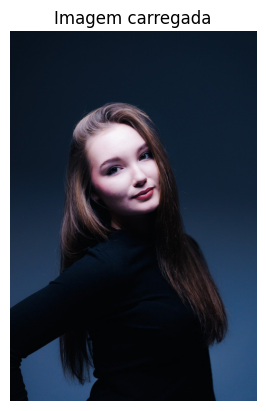

In [3]:
# Carregamento de imagem

# Caminho da imagem a ser testada
imagem_teste= "/content/teste_garota.jpg"

# Caminho das fotos de pessoas autorizadas
banco_autorizados= "autorizados/"

# Carregar imagem
imagem_bgr= cv2.imread(imagem_teste)

# Converter para vizualizar corretamente
imagem = cv2.cvtColor(imagem_bgr, cv2.COLOR_BGR2RGB)

#Visualizando a imagem
plt.imshow(imagem)
plt.title("Imagem carregada")
plt.axis("off")
plt.show()

In [5]:
# Compara a imagem de teste com as fotos que estão no banco de autorizados

resultado = DeepFace.find(
    img_path = imagem_teste,
    db_path = banco_autorizados,
    model_name = "VGG-Face",
    enforce_detection = False
)

if isinstance(resultado, list):
  resultado= resultado[0]

if resultado is not None and not resultado.empty:
  texto= "AUTORIZADO"
  cor= (0,255,0)
  print("AUTORIZADO")
else:
  texto= "NÃO AUTORIZADO"
  cor= (0,0,255)
  print("NÃO AUTORIZADO")

26-03-11 00:08:01 - Found 1 newly added image(s), 0 removed image(s), 0 replaced image(s).


Finding representations:   0%|          | 0/1 [00:00<?, ?it/s]Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/vgg_face_weights.h5
To: /root/.deepface/weights/vgg_face_weights.h5


26-03-11 00:08:03 - 🔗 vgg_face_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/vgg_face_weights.h5 to /root/.deepface/weights/vgg_face_weights.h5...



  0%|          | 0.00/580M [00:00<?, ?B/s]
  2%|▏         | 11.0M/580M [00:00<00:05, 102MB/s]
  6%|▌         | 32.0M/580M [00:00<00:03, 162MB/s]
  9%|▉         | 51.4M/580M [00:00<00:03, 174MB/s]
 14%|█▍        | 81.8M/580M [00:00<00:02, 222MB/s]
 18%|█▊        | 104M/580M [00:00<00:02, 188MB/s] 
 21%|██▏       | 124M/580M [00:00<00:03, 116MB/s]
 24%|██▍       | 139M/580M [00:00<00:03, 124MB/s]
 28%|██▊       | 162M/580M [00:01<00:02, 146MB/s]
 31%|███       | 180M/580M [00:01<00:03, 130MB/s]
 34%|███▍      | 200M/580M [00:01<00:02, 141MB/s]
 37%|███▋      | 216M/580M [00:01<00:03, 117MB/s]
 40%|███▉      | 230M/580M [00:01<00:03, 114MB/s]
 43%|████▎     | 248M/580M [00:01<00:02, 126MB/s]
 45%|████▌     | 262M/580M [00:03<00:11, 26.5MB/s]
 47%|████▋     | 272M/580M [00:06<00:24, 12.4MB/s]
 49%|████▉     | 286M/580M [00:06<00:17, 16.7MB/s]
 52%|█████▏    | 299M/580M [00:06<00:12, 22.2MB/s]
 54%|█████▍    | 314M/580M [00:06<00:08, 30.2MB/s]
 56%|█████▌    | 325M/580M [00:06<00:06, 36.5M

26-03-11 00:08:22 - There are now 1 representations in ds_model_vggface_detector_opencv_aligned_normalization_base_expand_0.pkl
26-03-11 00:08:22 - Searching /content/teste_garota.jpg in 1 length datastore
26-03-11 00:08:23 - find function duration 22.393925666809082 seconds
AUTORIZADO


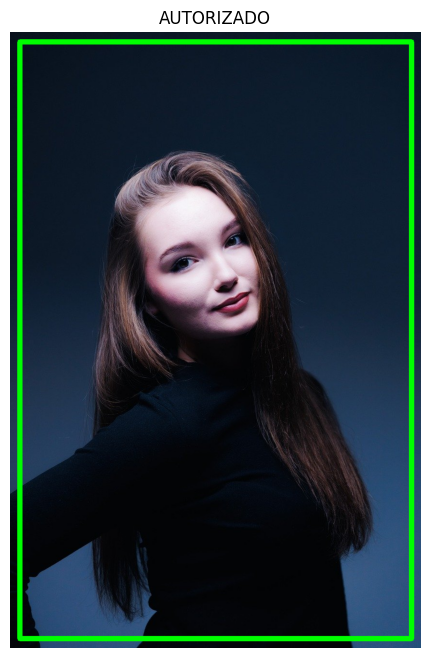

In [6]:
# Desenhando retangulo no rosto detectado
altura, largura, _ = imagem.shape
cv2.rectangle(imagem, (20,20), (largura - 20, altura - 20), cor, 10)

# Mostrando a imagem
plt.figure(figsize=(10,8))
plt.imshow(imagem)
plt.title(f'{texto}')
plt.axis("off")
plt.show()